# 🏠 House Price Prediction — Machine Learning Project

## 📌 Project Overview

This project predicts the **selling price of a house** using its features such as:

- Overall quality
- Living area
- Number of rooms
- Garage
- Basement
- House age
- And other property features

### 🎯 Goal

Build a Machine Learning **Regression model** that learns from historical house data and predicts the price of a new house.

### 🔄 ML Workflow

**Dataset → EDA → Data Cleaning → Encoding → Feature Engineering → Train/Test Split → Scaling → Model Training → Evaluation → Model Comparison → Cross-Validation → Hyperparameter Tuning → Save Model → Prediction**

### 🤖 Models Used

- Linear Regression
- Ridge Regression
- Lasso Regression
- Decision Tree Regressor
- Random Forest Regressor

### 🏆 Best Model

**Random Forest Regressor**

Final Test R²: **88.50%**

The model achieved approximately:

- **MAE:** $17,587
- **RMSE:** $29,700
- **R²:** 88.50%

### 🛠️ Libraries Used

- **Pandas** → Data manipulation
- **NumPy** → Numerical calculations
- **Matplotlib** → Visualization
- **Seaborn** → Statistical visualization
- **Scikit-learn** → Machine Learning
- **Joblib** → Save and load the trained model

# 🏠 House Price Prediction

## 1. Import Libraries

In [1]:
%pip install pandas numpy matplotlib seaborn scikit-learn joblib

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd

df = pd.read_csv("train.csv")
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


## 3. Understand the Dataset

In [4]:
df.shape

(1460, 81)

## 4. Check Missing Values

In [5]:
df.isnull().sum()

Id                 0
MSSubClass         0
MSZoning           0
LotFrontage      259
LotArea            0
                ... 
MoSold             0
YrSold             0
SaleType           0
SaleCondition      0
SalePrice          0
Length: 81, dtype: int64

In [6]:
df.isnull().sum()[df.isnull().sum() > 0]

LotFrontage      259
Alley           1369
MasVnrType       872
MasVnrArea         8
BsmtQual          37
BsmtCond          37
BsmtExposure      38
BsmtFinType1      37
BsmtFinType2      38
Electrical         1
FireplaceQu      690
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
PoolQC          1453
Fence           1179
MiscFeature     1406
dtype: int64

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

In [8]:
df.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


## 5. Understand the Target Variable

In [9]:
df["SalePrice"].describe()

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

## 6. Visualize the Target Variable

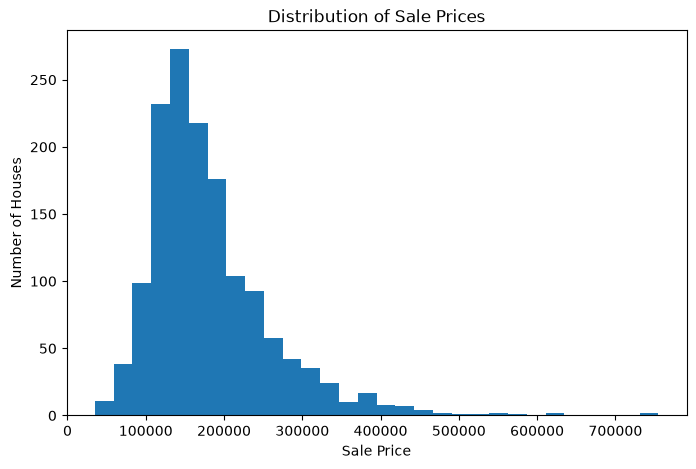

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(df["SalePrice"], bins=30)
plt.xlabel("Sale Price")
plt.ylabel("Number of Houses")
plt.title("Distribution of Sale Prices")
plt.show()

In [11]:
df.select_dtypes(include="number").columns

Index(['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual',
       'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1',
       'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd',
       'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF',
       'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea',
       'MiscVal', 'MoSold', 'YrSold', 'SalePrice'],
      dtype='str')

## 8. Analyze Feature Relationships

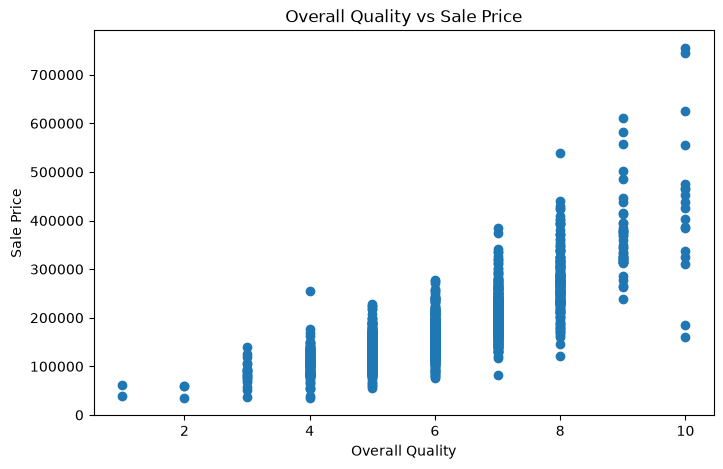

In [12]:
plt.figure(figsize=(8, 5))
plt.scatter(df["OverallQual"], df["SalePrice"])
plt.xlabel("Overall Quality")
plt.ylabel("Sale Price")
plt.title("Overall Quality vs Sale Price")
plt.show()

## 9. Check Correlation

In [13]:
correlation = df.select_dtypes(include="number").corr()["SalePrice"].sort_values(ascending=False)

correlation

SalePrice        1.000000
OverallQual      0.790982
GrLivArea        0.708624
GarageCars       0.640409
GarageArea       0.623431
TotalBsmtSF      0.613581
1stFlrSF         0.605852
FullBath         0.560664
TotRmsAbvGrd     0.533723
YearBuilt        0.522897
YearRemodAdd     0.507101
GarageYrBlt      0.486362
MasVnrArea       0.477493
Fireplaces       0.466929
BsmtFinSF1       0.386420
LotFrontage      0.351799
WoodDeckSF       0.324413
2ndFlrSF         0.319334
OpenPorchSF      0.315856
HalfBath         0.284108
LotArea          0.263843
BsmtFullBath     0.227122
BsmtUnfSF        0.214479
BedroomAbvGr     0.168213
ScreenPorch      0.111447
PoolArea         0.092404
MoSold           0.046432
3SsnPorch        0.044584
BsmtFinSF2      -0.011378
BsmtHalfBath    -0.016844
MiscVal         -0.021190
Id              -0.021917
LowQualFinSF    -0.025606
YrSold          -0.028923
OverallCond     -0.077856
MSSubClass      -0.084284
EnclosedPorch   -0.128578
KitchenAbvGr    -0.135907
Name: SalePr

## 10. Visualize Correlations

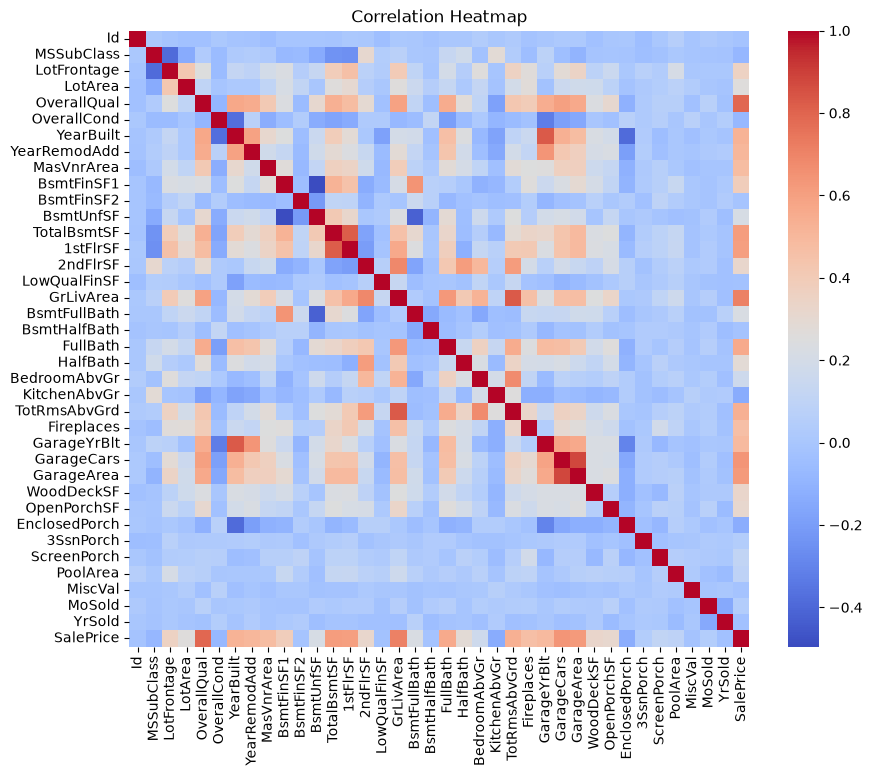

In [15]:
import seaborn as sns
plt.figure(figsize=(10, 8))

sns.heatmap(
    df.select_dtypes(include="number").corr(),
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

In [16]:
missing = df.isnull().sum()
missing[missing > 0]

LotFrontage      259
Alley           1369
MasVnrType       872
MasVnrArea         8
BsmtQual          37
BsmtCond          37
BsmtExposure      38
BsmtFinType1      37
BsmtFinType2      38
Electrical         1
FireplaceQu      690
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
PoolQC          1453
Fence           1179
MiscFeature     1406
dtype: int64

In [17]:
none_cols = [
    "Alley",
    "MasVnrType",
    "BsmtQual",
    "BsmtCond",
    "BsmtExposure",
    "BsmtFinType1",
    "BsmtFinType2",
    "FireplaceQu",
    "GarageType",
    "GarageFinish",
    "GarageQual",
    "GarageCond",
    "PoolQC",
    "Fence",
    "MiscFeature"
]

df[none_cols] = df[none_cols].fillna("None")

In [18]:
num_cols = df.select_dtypes(include="number").columns

df[num_cols] = df[num_cols].fillna(df[num_cols].median())

In [19]:
df.isnull().sum()[df.isnull().sum() > 0]

Electrical    1
dtype: int64

In [20]:
df["Electrical"] = df["Electrical"].fillna(df["Electrical"].mode()[0])

In [21]:
df.isnull().sum()[df.isnull().sum() > 0]

Series([], dtype: int64)

# 15. Encode Categorical Features

In [22]:
df.select_dtypes(include="object").columns

/var/folders/gp/gtnxns394x707t5xd238q7tr0000gq/T/ipykernel_98112/1196084386.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.select_dtypes(include="object").columns


Index(['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities',
       'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
       'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation',
       'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
       'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual',
       'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual',
       'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature',
       'SaleType', 'SaleCondition'],
      dtype='str')

In [23]:
df = pd.get_dummies(df, columns=df.select_dtypes(include="object").columns, dtype=int)

/var/folders/gp/gtnxns394x707t5xd238q7tr0000gq/T/ipykernel_98112/1495455501.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df = pd.get_dummies(df, columns=df.select_dtypes(include="object").columns, dtype=int)


In [24]:
df.shape

(1460, 304)

# 17. Separate Features (X) and Target (y)

In [25]:
X = df.drop("SalePrice", axis=1)
y = df["SalePrice"]

In [26]:
print(X.shape)
print(y.shape)

(1460, 303)
(1460,)


# 18. Train/Test Split

In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [28]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(1168, 303)
(292, 303)
(1168,)
(292,)


# 19. Feature Scaling

In [29]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [30]:
scaler.fit_transform(X_train)

array([[-1.11928402, -0.8667643 , -0.00419319, ..., -0.12510865,
         0.46001984, -0.30263639],
       [ 0.79046412,  0.07410996, -0.49395768, ..., -0.12510865,
         0.46001984, -0.30263639],
       [-0.21615189, -0.63154574, -0.13776532, ..., -0.12510865,
         0.46001984, -0.30263639],
       ...,
       [ 1.32669882, -0.8667643 , -0.44943363, ..., -0.12510865,
         0.46001984, -0.30263639],
       [ 0.30597137, -0.16110861, -0.67205386, ..., -0.12510865,
         0.46001984, -0.30263639],
       [ 0.93157852,  1.48542135, -0.76110194, ..., -0.12510865,
         0.46001984, -0.30263639]], shape=(1168, 303))

In [31]:
scaler.transform(X_test)

array([[ 0.38123238, -0.8667643 , -0.00419319, ..., -0.12510865,
         0.46001984, -0.30263639],
       [ 0.88218848,  0.07410996,  1.24248005, ..., -0.12510865,
         0.46001984, -0.30263639],
       [-0.74533088, -0.63154574, -0.62752981, ..., -0.12510865,
         0.46001984, -0.30263639],
       ...,
       [ 0.16956079,  0.07410996, -0.3158615 , ..., -0.12510865,
         0.46001984, -0.30263639],
       [-0.18557711,  0.30932853, -0.44943363, ..., -0.12510865,
         0.46001984, -0.30263639],
       [-0.01859174, -0.8667643 , -0.00419319, ..., -0.12510865,
         0.46001984, -0.30263639]], shape=(292, 303))

In [32]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](303,)","[ 129.09, 729.82, 425.96,...,-580.97,-258.9 ,1687.84]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,1.814e+05
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,303
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(248)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](303,)","[149.51,103.57, 94.44,..., 0. , 0. , 0. ]"


# 21. Make Predictions


In [33]:
y_pred = model.predict(X_test_scaled)

In [34]:
y_pred[:5]

array([160201.42730634, 343035.07329849,  90079.26155315, 176365.62603807,
       321471.78617875])

# 22. Evaluate the Model — MAE

In [36]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, y_pred)

print("MAE:", mae)

MAE: 21088.950253215942


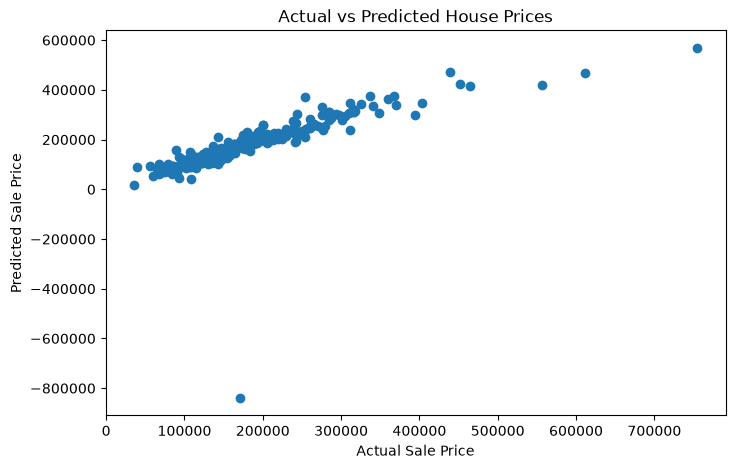

In [37]:
plt.figure(figsize=(8, 5))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Sale Price")
plt.ylabel("Predicted Sale Price")
plt.title("Actual vs Predicted House Prices")

plt.show()

In [38]:
from sklearn.metrics import r2_score

train_pred = model.predict(X_train_scaled)
test_pred = model.predict(X_test_scaled)

train_r2 = r2_score(y_train, train_pred)
test_r2 = r2_score(y_test, test_pred)

print("Training R²:", train_r2)
print("Testing R²:", test_r2)

Training R²: 0.9400624492338716
Testing R²: 0.4440408639898191


# 24. Try a Better Model — Ridge Regression

In [39]:
from sklearn.linear_model import Ridge

ridge_model = Ridge(alpha=1.0)

ridge_model.fit(X_train_scaled, y_train)

ridge_pred = ridge_model.predict(X_test_scaled)

In [40]:
ridge_r2 = r2_score(y_test, ridge_pred)

print("Ridge R²:", ridge_r2)

Ridge R²: 0.8847371395897297


In [41]:
ridge_train_pred = ridge_model.predict(X_train_scaled)

ridge_train_r2 = r2_score(y_train, ridge_train_pred)
ridge_test_r2 = r2_score(y_test, ridge_pred)

print("Ridge Training R²:", ridge_train_r2)
print("Ridge Testing R²:", ridge_test_r2)

Ridge Training R²: 0.9378696110395582
Ridge Testing R²: 0.8847371395897297


# 26. Try Lasso Regression

In [42]:
from sklearn.linear_model import Lasso

lasso_model = Lasso(alpha=1.0, max_iter=10000)

lasso_model.fit(X_train_scaled, y_train)

lasso_pred = lasso_model.predict(X_test_scaled)

lasso_r2 = r2_score(y_test, lasso_pred)

print("Lasso R²:", lasso_r2)

Lasso R²: 0.5474639875783455


/Users/waleedkhokhar/Library/Python/3.14/lib/python/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.507021e+11, tolerance: 6.967e+08
  model = cd_fast.enet_coordinate_descent(


In [43]:
lasso_model = Lasso(alpha=1.0, max_iter=100000)

lasso_model.fit(X_train_scaled, y_train)

lasso_pred = lasso_model.predict(X_test_scaled)

lasso_r2 = r2_score(y_test, lasso_pred)

print("Lasso R²:", lasso_r2)

Lasso R²: 0.47361067051825045


# 27. Decision Tree Regression 🌳

In [44]:
from sklearn.tree import DecisionTreeRegressor

tree_model = DecisionTreeRegressor(random_state=42)

tree_model.fit(X_train, y_train)

tree_pred = tree_model.predict(X_test)

tree_r2 = r2_score(y_test, tree_pred)

print("Decision Tree R²:", tree_r2)

Decision Tree R²: 0.7635333260379079


# now Ridge


In [45]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest R²:", rf_r2)

Random Forest R²: 0.8913474579750168


In [46]:
rf_train_pred = rf_model.predict(X_train)

rf_train_r2 = r2_score(y_train, rf_train_pred)

print("Random Forest Training R²:", rf_train_r2)
print("Random Forest Testing R²:", rf_r2)

Random Forest Training R²: 0.9795488336205807
Random Forest Testing R²: 0.8913474579750168


28. Random Forest — Control Tree Depth 🌲

In [47]:
rf_model_2 = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    random_state=42
)

rf_model_2.fit(X_train, y_train)

rf_pred_2 = rf_model_2.predict(X_test)

rf_r2_2 = r2_score(y_test, rf_pred_2)

print("Random Forest R²:", rf_r2_2)

Random Forest R²: 0.8920880311753343


In [48]:
from sklearn.model_selection import GridSearchCV

In [49]:
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [10, 15, 20],
    "min_samples_split": [2, 5]
}

In [50]:
grid_search = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [10, 15, ...], 'min_samples_split': [2, 5], 'n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the 

In [52]:
print("Best Parameters:", grid_search.best_params_)
print("Best CV R²:", grid_search.best_score_)

Best Parameters: {'max_depth': 20, 'min_samples_split': 5, 'n_estimators': 100}
Best CV R²: 0.8398088703283391


In [53]:
best_rf = grid_search.best_estimator_

best_rf_pred = best_rf.predict(X_test)

best_rf_r2 = r2_score(y_test, best_rf_pred)

print("Tuned Random Forest Test R²:", best_rf_r2)

Tuned Random Forest Test R²: 0.8851113565222423


# 🏠 House Price Prediction — Regression

## 1. Import Libraries
- Imported Pandas, NumPy, Matplotlib, Seaborn, Scikit-learn, and Joblib.

## 2. Load Dataset
- Loaded the Kaggle House Prices dataset using Pandas.

## 3. Understand the Dataset
- Checked dataset shape using `df.shape`
- Inspected data types and missing values using `df.info()`
- Generated statistical summaries using `df.describe()`

## 4. Understand the Target Variable
- Identified `SalePrice` as the target variable.
- Analyzed its mean, median, minimum, maximum, and spread.

## 5. Exploratory Data Analysis (EDA)
- Visualized the distribution of house prices.
- Explored numerical features.
- Analyzed important relationships such as `OverallQual` vs `SalePrice`.
- Calculated correlations with the target.
- Visualized correlations using a heatmap.

## 6. Data Cleaning
- Identified missing values.
- Filled categorical missing values where missing meant "feature not present".
- Filled numerical missing values using the median.
- Filled the remaining categorical missing value using the mode.
- Verified that no missing values remained.

## 7. Encode Categorical Features
- Converted categorical features into numerical features using One-Hot Encoding.
- Dataset expanded from 79 original features to 303 input features.

## 8. Separate Features and Target
- `X` = input features
- `y` = `SalePrice` target

## 9. Train/Test Split
- Split the dataset into:
  - 80% training data
  - 20% testing data

## 10. Feature Scaling
- Applied `StandardScaler`.
- Used `fit_transform()` only on training data.
- Used `transform()` on test data to avoid data leakage.

## 11. Train ML Models

### Linear Regression
- Test R²: **44.40%**
- Showed significant overfitting.

### Ridge Regression
- Test R²: **88.47%**
- Strong improvement through regularization.

### Lasso Regression
- Test R²: **47.36%**
- Tested regularization and increased `max_iter` to achieve convergence.

### Decision Tree Regression
- Test R²: **76.35%**
- Captured non-linear relationships but performed worse than Ridge and Random Forest.

### Random Forest Regression
- Test R²: **89.13%**
- Currently the best-performing model.

## 12. Overfitting Analysis
- Compared training and testing R².
- Random Forest:
  - Training R²: **97.95%**
  - Testing R²: **89.13%**
- Identified some overfitting but good generalization.

## 13. Hyperparameter Tuning
- Used `GridSearchCV` with 5-fold cross-validation.
- Tested:
  - `n_estimators`
  - `max_depth`
  - `min_samples_split`

Best parameters:
```python
{
    "max_depth": 20,
    "min_samples_split": 5,
    "n_estimators": 100
}



## 🔜 What we still need to do

```markdown
## 14. Cross-Validation & Model Reliability
- Compare models using cross-validation.
- Check whether the model consistently performs well across different data splits.

## 15. Feature Engineering
- Improve the input features.
- Remove unnecessary features such as `Id`.
- Create useful house-related features.

## 16. Final Model Evaluation
- Compare all models using:
  - MAE
  - MSE
  - RMSE
  - R²

## 17. Select the Final Model
- Choose the model based on performance and generalization, not simply the highest training score.

## 18. Save the Final Model
- Save the trained model using Joblib.

## 19. Load the Model
- Load the saved model back into Python.

## 20. Make Predictions on New Houses
- Provide new house information.
- Preprocess it in the same way as the training data.
- Predict its estimated sale price.

## 21. Final Project Cleanup
- Clean notebook.
- Add explanations.
- Organize visualizations.
- Add a professional README.
- Prepare the project for the portfolio.

## 22. Optional Deployment
- Later, expose the model through FastAPI and create an API for house-price predictions.

# 31. Cross-Validation

In [54]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    rf_model,
    X_train,
    y_train,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

print("CV Scores:", cv_scores)
print("Mean CV R²:", cv_scores.mean())

CV Scores: [0.87318993 0.75544415 0.80968633 0.87745226 0.8711134 ]
Mean CV R²: 0.8373772146181931


# 32. Feature Engineering


In [55]:
df["TotalSF"] = df["TotalBsmtSF"] + df["1stFlrSF"] + df["2ndFlrSF"]

df[["TotalBsmtSF", "1stFlrSF", "2ndFlrSF", "TotalSF"]].head()

,TotalBsmtSF,1stFlrSF,2ndFlrSF,TotalSF
0,856,856,854,2566
1,1262,1262,0,2524
2,920,920,866,2706
3,756,961,756,2473
4,1145,1145,1053,3343


# More Feature Engineering


In [56]:
# Total bathrooms
df["TotalBathrooms"] = (
    df["FullBath"]
    + 0.5 * df["HalfBath"]
    + df["BsmtFullBath"]
    + 0.5 * df["BsmtHalfBath"]
)

# Total porch area
df["TotalPorchSF"] = (
    df["OpenPorchSF"]
    + df["3SsnPorch"]
    + df["EnclosedPorch"]
    + df["ScreenPorch"]
    + df["WoodDeckSF"]
)

# House age
df["HouseAge"] = df["YrSold"] - df["YearBuilt"]

df[["TotalBathrooms", "TotalPorchSF", "HouseAge"]].head()

,TotalBathrooms,TotalPorchSF,HouseAge
0,3.5,61,5
1,2.5,298,31
2,3.5,42,7
3,2.0,307,91
4,3.5,276,8


In [ ]:
# Total bathrooms
df["TotalBathrooms"] = (
    df["FullBath"]
    + 0.5 * df["HalfBath"]
    + df["BsmtFullBath"]
    + 0.5 * df["BsmtHalfBath"]
)

# Total porch area
df["TotalPorchSF"] = (
    df["OpenPorchSF"]
    + df["3SsnPorch"]
    + df["EnclosedPorch"]
    + df["ScreenPorch"]
    + df["WoodDeckSF"]
)

# House age
df["HouseAge"] = df["YrSold"] - df["YearBuilt"]

df[["TotalBathrooms", "TotalPorchSF", "HouseAge"]].head()

,TotalBathrooms,TotalPorchSF,HouseAge
0,3.5,61,5
1,2.5,298,31
2,3.5,42,7
3,2.0,307,91
4,3.5,276,8


In [57]:
X = df.drop("SalePrice", axis=1)
y = df["SalePrice"]

print(X.shape)
print(y.shape)

(1460, 307)
(1460,)


In [58]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(1168, 307)
(292, 307)


In [59]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(X_train_scaled.shape)
print(X_test_scaled.shape)

(1168, 307)
(292, 307)


# Retrain Random Forest


In [61]:
from sklearn.ensemble import RandomForestRegressor

final_rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

final_rf.fit(X_train, y_train)

final_pred = final_rf.predict(X_test)

final_r2 = r2_score(y_test, final_pred)

print("Final Random Forest R²:", final_r2)

Final Random Forest R²: 0.8850008540033426


# Evaluation


In [63]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, final_pred)
mse = mean_squared_error(y_test, final_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, final_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R²:", r2)

MAE: 17587.19268835617
MSE: 882080963.3422998
RMSE: 29699.84786732585
R²: 0.8850008540033426


In [64]:
import joblib

joblib.dump(final_rf, "house_price_model.pkl")

print("Model saved successfully!")

Model saved successfully!


## ML Concepts Used in This Project

- **Pandas** → Load, inspect, clean, and manipulate the dataset.
- **NumPy** → Numerical calculations, such as RMSE.
- **Matplotlib** → Create visualizations and plots.
- **Seaborn** → Create the correlation heatmap.
- **EDA (Exploratory Data Analysis)** → Understand the dataset, distributions, relationships, and patterns.
- **Missing Value Handling** → Filled missing numerical and categorical values.
- **One-Hot Encoding** → Converted categorical features into numerical 0/1 columns.
- **Feature Engineering** → Created useful features such as `TotalSF`, `TotalBathrooms`, `TotalPorchSF`, and `HouseAge`.
- **X and y** → `X` contains input features; `y` contains the target `SalePrice`.
- **Train/Test Split** → Used 80% data for training and 20% for testing.
- **Feature Scaling** → Used `StandardScaler` for Linear, Ridge, and Lasso models.
- **Linear Regression** → Basic regression model.
- **Ridge Regression** → Linear Regression with regularization to reduce overfitting.
- **Lasso Regression** → Regularized regression that can reduce the importance of features.
- **Decision Tree Regressor** → Predicts prices using decision rules.
- **Random Forest Regressor** → Combines many decision trees for stronger predictions.
- **MAE** → Average absolute prediction error.
- **MSE** → Average squared prediction error.
- **RMSE** → Prediction error in the same unit as house prices.
- **R² Score** → Measures how well the model explains price variation.
- **Overfitting Check** → Compared training and testing R².
- **Cross-Validation** → Tested model performance across multiple data splits.
- **GridSearchCV** → Automatically searched for better Random Forest hyperparameters.
- **Hyperparameters** → Settings such as `n_estimators`, `max_depth`, and `min_samples_split`.
- **Model Comparison** → Compared different models to find the best performer.
- **Joblib** → Saved the trained model for future predictions.